In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import optuna
import shap
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GaussianNoise, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

In [2]:
feature_names = ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12']
df = pd.read_csv("all_data.csv", names=feature_names + ['class'], header=None)
df['class'] = df['class'].astype(str).map({'1': 1, '0': 0})
df = df.dropna()

x = df[feature_names].values
y = df['class'].values.astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, stratify=y, random_state=42)

imbalance_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# --- 3. SCALING ---
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Cross-Validation Generator
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Global trackers
best_models = {}
evaluation_results = {}
latency_results = {}

In [3]:
print("Running Optuna Optimization for GBDTs (5-Fold CV)...")

# Force native Python float to prevent sklearn clone() type-mismatch errors
clean_ratio = float(imbalance_ratio) 

# --- 1. XGBOOST OPTIMIZATION ---
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': clean_ratio,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**param)
    return cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc').mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=15) 
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, scale_pos_weight=clean_ratio, random_state=42)

start_train = time.time()
best_xgb.fit(x_train, y_train)
latency_results['XGBoost_TrainTime'] = time.time() - start_train
best_models['XGBoost'] = best_xgb
print(f"XGBoost optimized. Best CV AUC: {study_xgb.best_value:.4f}")

# --- 2. LIGHTGBM OPTIMIZATION ---
def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': clean_ratio,
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }
    model = lgb.LGBMClassifier(**param)
    return cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc').mean()

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=15) 
best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, scale_pos_weight=clean_ratio, random_state=42, verbosity=-1)

start_train = time.time()
best_lgb.fit(x_train, y_train)
latency_results['LightGBM_TrainTime'] = time.time() - start_train
best_models['LightGBM'] = best_lgb
print(f"LightGBM optimized. Best CV AUC: {study_lgb.best_value:.4f}")

# --- 3. CATBOOST OPTIMIZATION ---
def objective_cb(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'scale_pos_weight': clean_ratio,
        'verbose': False,
        'random_seed': 42
    }
    model = CatBoostClassifier(**param)
    return cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc').mean()

study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=15)
best_cb = CatBoostClassifier(**study_cb.best_params, scale_pos_weight=clean_ratio, verbose=0)

start_train = time.time()
best_cb.fit(x_train, y_train)
latency_results['CatBoost_TrainTime'] = time.time() - start_train
best_models['CatBoost'] = best_cb
print(f"CatBoost optimized. Best CV AUC: {study_cb.best_value:.4f}")

Running Optuna Optimization for GBDTs (5-Fold CV)...
XGBoost optimized. Best CV AUC: 0.9904


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

LightGBM optimized. Best CV AUC: 0.9916
CatBoost optimized. Best CV AUC: 0.9934


In [4]:
print("Running Optuna Optimization for Neural Network...")

def objective_nn(trial):
    # 1. Define the dynamic search space
    dr = trial.suggest_float('dropout_rate', 0.1, 0.5)
    u1 = trial.suggest_categorical('units_layer_1', [16, 32, 64])
    u2 = trial.suggest_categorical('units_layer_2', [8, 16, 32])
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    # 2. Internal Train/Val split (Running full 5-Fold CV on NNs is too slow for standard machines)
    x_t, x_v, y_t, y_v = train_test_split(x_train_scaled, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # 3. Build architecture
    model = Sequential([
        GaussianNoise(0.1, input_shape=(x_train_scaled.shape[1],)), 
        Dense(u1, activation='elu'),
        BatchNormalization(),
        Dropout(dr),
        Dense(u2, activation="elu"),
        BatchNormalization(),
        Dropout(dr),
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["auc"])
    
    # 4. Train with Early Stopping to prevent overfitting and speed up search
    early_stop = EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True)
    
    history = model.fit(x_t, y_t, validation_data=(x_v, y_v), 
                        epochs=100, batch_size=32, verbose=0,
                        callbacks=[early_stop])
    
    # Return the highest Validation AUC achieved during this trial
    return max(history.history['val_auc'])

# Run Optimization
study_nn = optuna.create_study(direction='maximize')
study_nn.optimize(objective_nn, n_trials=15) 

print(f"NN optimized. Best Val AUC: {study_nn.best_value:.4f} \n(Params: {study_nn.best_params})")

# --- TRAIN FINAL MODEL ---
best_p = study_nn.best_params

best_nn = Sequential([
    GaussianNoise(0.1, input_shape=(x_train_scaled.shape[1],)), 
    Dense(best_p['units_layer_1'], activation='elu'),
    BatchNormalization(),
    Dropout(best_p['dropout_rate']),
    Dense(best_p['units_layer_2'], activation="elu"),
    BatchNormalization(),
    Dropout(best_p['dropout_rate']),
    Dense(1, activation="sigmoid")
])

best_nn.compile(optimizer=Adam(learning_rate=best_p['learning_rate']), loss="binary_crossentropy", metrics=["auc"])

start_train = time.time()
# Train on the FULL training set using the best parameters
best_nn.fit(x_train_scaled, y_train, epochs=75, batch_size=32, verbose=0)
latency_results['Deep Neural Network_TrainTime'] = time.time() - start_train
best_models['Deep Neural Network'] = best_nn

Running Optuna Optimization for Neural Network...


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/regula

NN optimized. Best Val AUC: 1.0000 
(Params: {'dropout_rate': 0.44886334070535505, 'units_layer_1': 16, 'units_layer_2': 8, 'learning_rate': 0.007471723968948666})


In [5]:
print("Benchmarking Models on Holdout Test Set...")

for name, model in best_models.items():
    # 1. Inference Latency (Time taken to predict on test set)
    start_infer = time.time()
    
    if name == 'Deep Neural Network':
        y_probs = model.predict(x_test_scaled, verbose=0).ravel()
        y_pred = (y_probs > 0.5).astype(int)
    else:
        y_probs = model.predict_proba(x_test)[:, 1]
        y_pred = model.predict(x_test)
        
    infer_time = time.time() - start_infer
    
    # Calculate Latency per 1000 samples (in milliseconds)
    latency_ms = (infer_time / len(x_test)) * 1000
    latency_results[f'{name}_Latency_ms'] = latency_ms

    # 2. Performance Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_probs)
    
    evaluation_results[name] = {'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc}
    print(f"[{name}] AUC: {auc:.4f} | Latency: {latency_ms:.2f} ms/1k samples")

Benchmarking Models on Holdout Test Set...
[XGBoost] AUC: 0.9849 | Latency: 0.03 ms/1k samples
[LightGBM] AUC: 0.9698 | Latency: 0.02 ms/1k samples
[CatBoost] AUC: 0.9792 | Latency: 0.02 ms/1k samples
[Deep Neural Network] AUC: 0.9773 | Latency: 1.55 ms/1k samples


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Generating SHAP values (This may take a moment for the NN)...


/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_135
Received: inputs=['Tensor(shape=(100, 12))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_135
Received: inputs=['Tensor(shape=(200, 12))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_135
Received: inputs=['Tensor(shape=(46

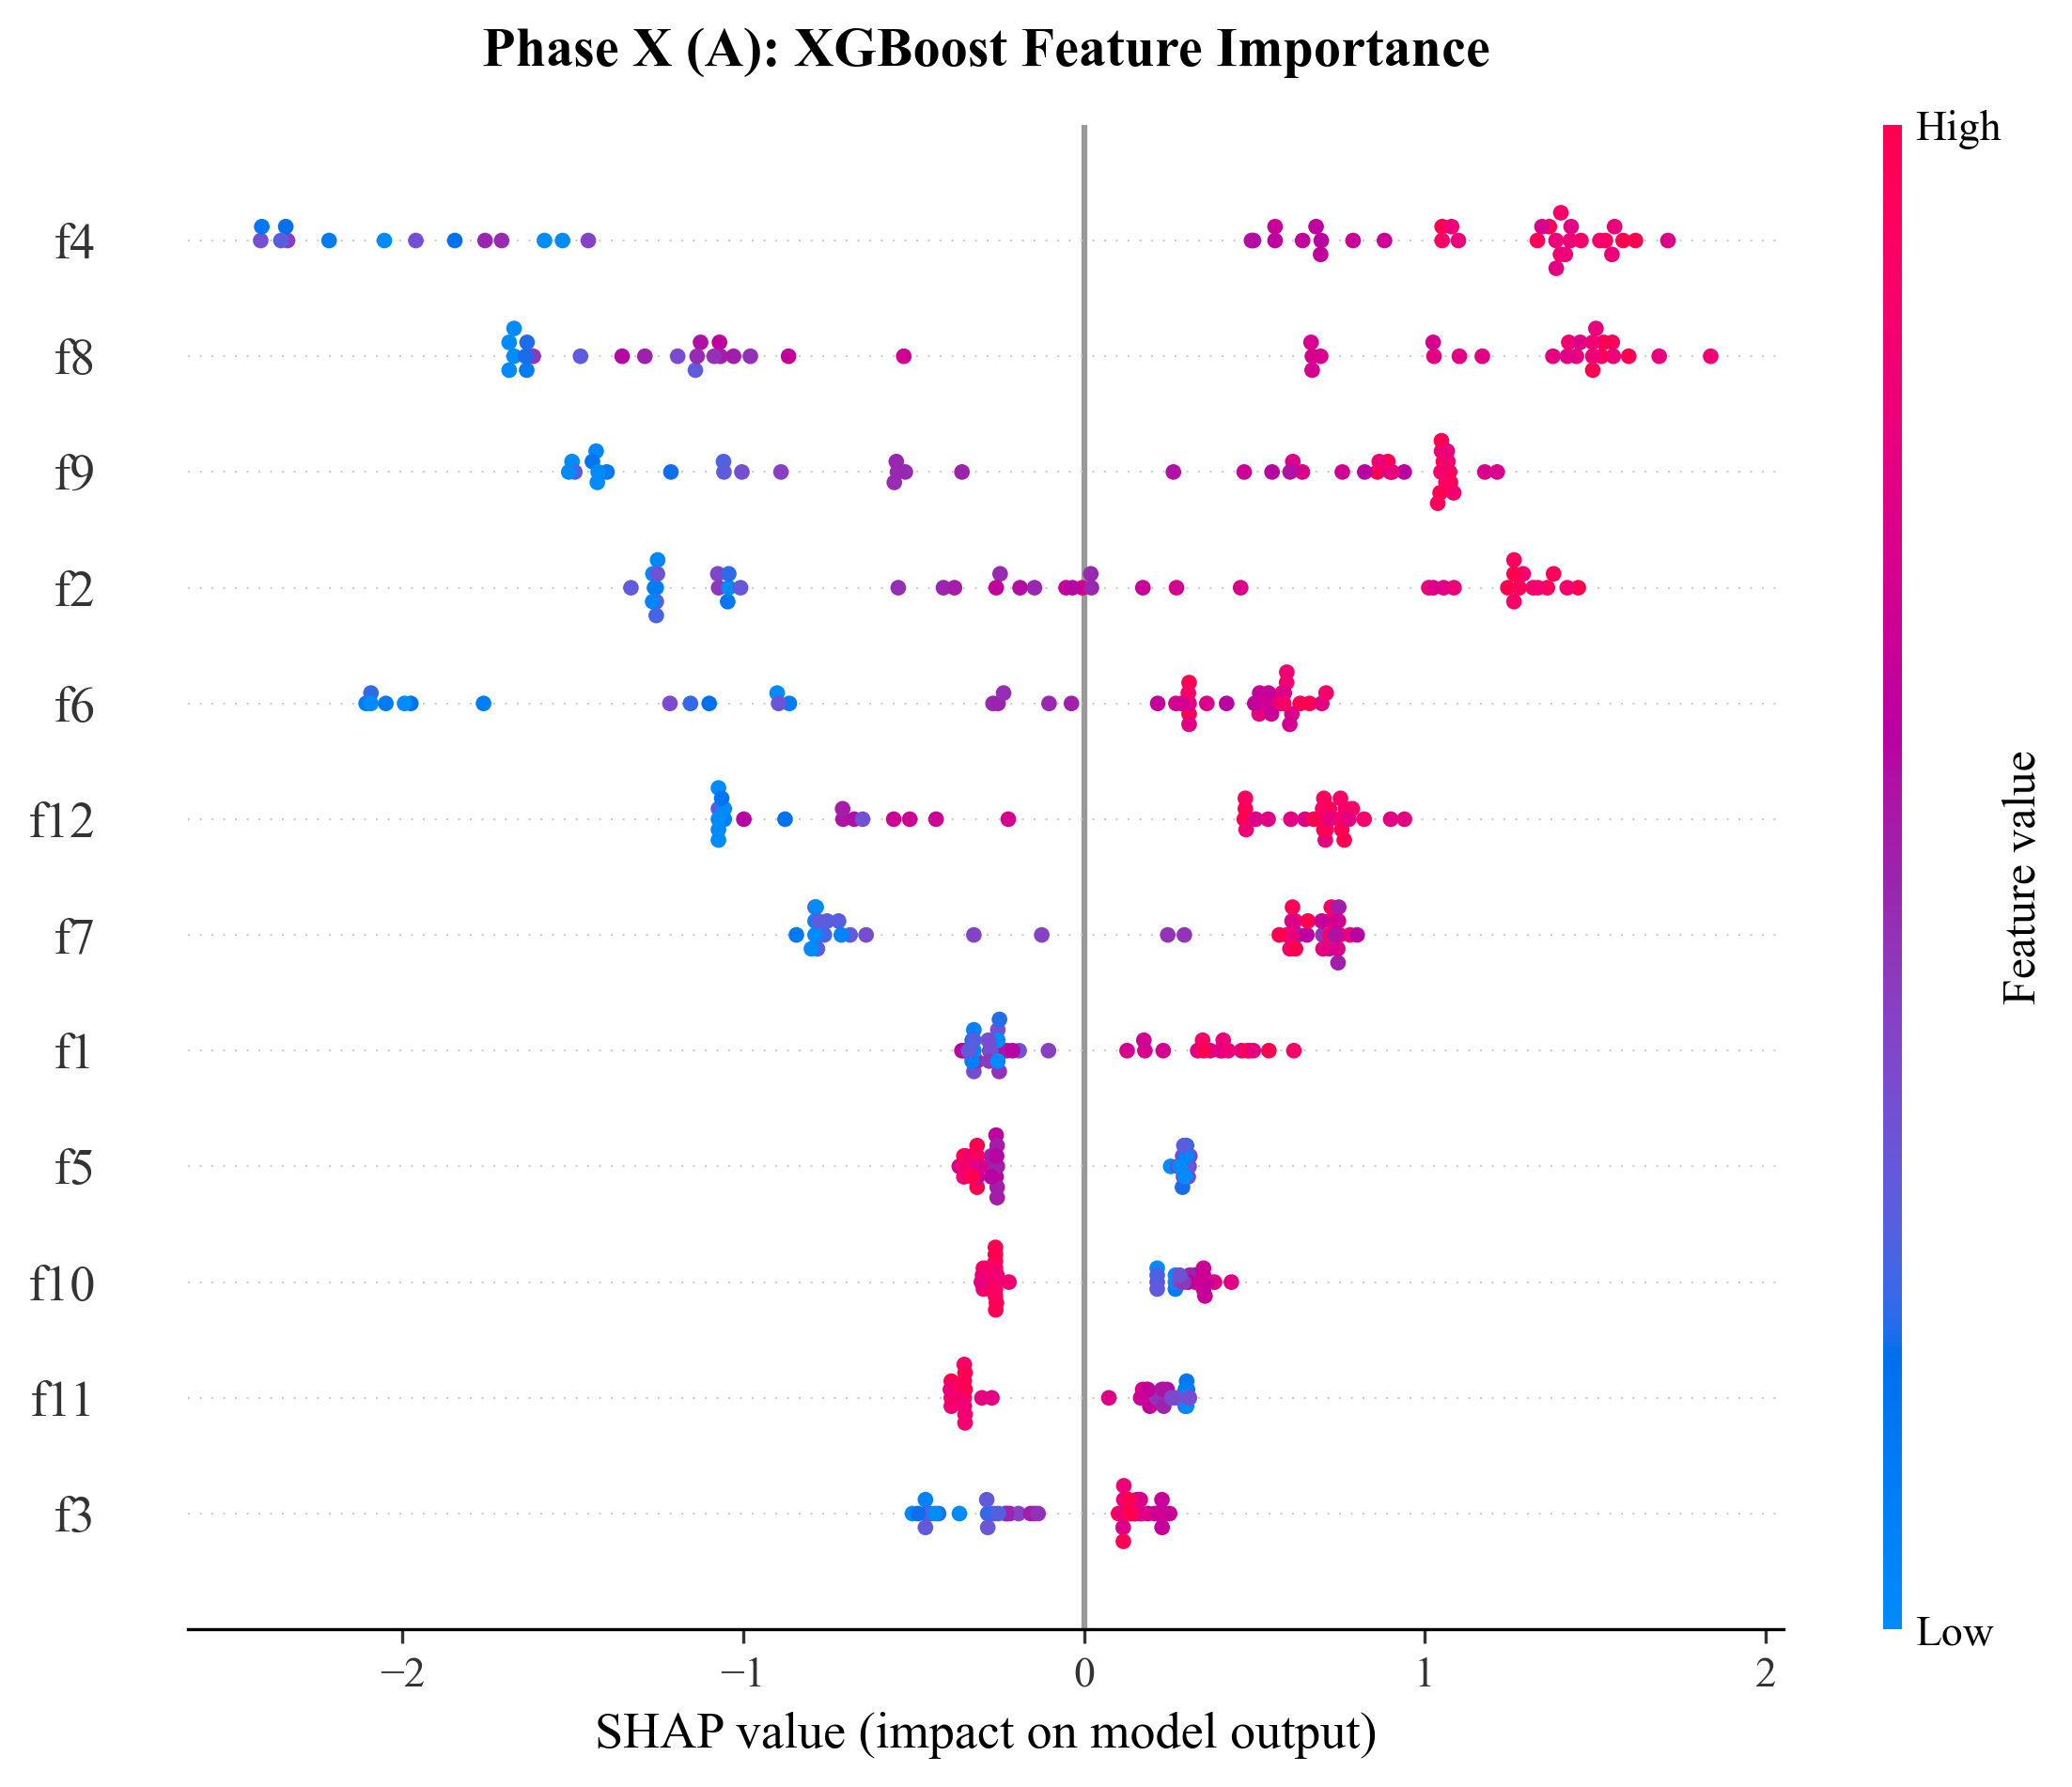

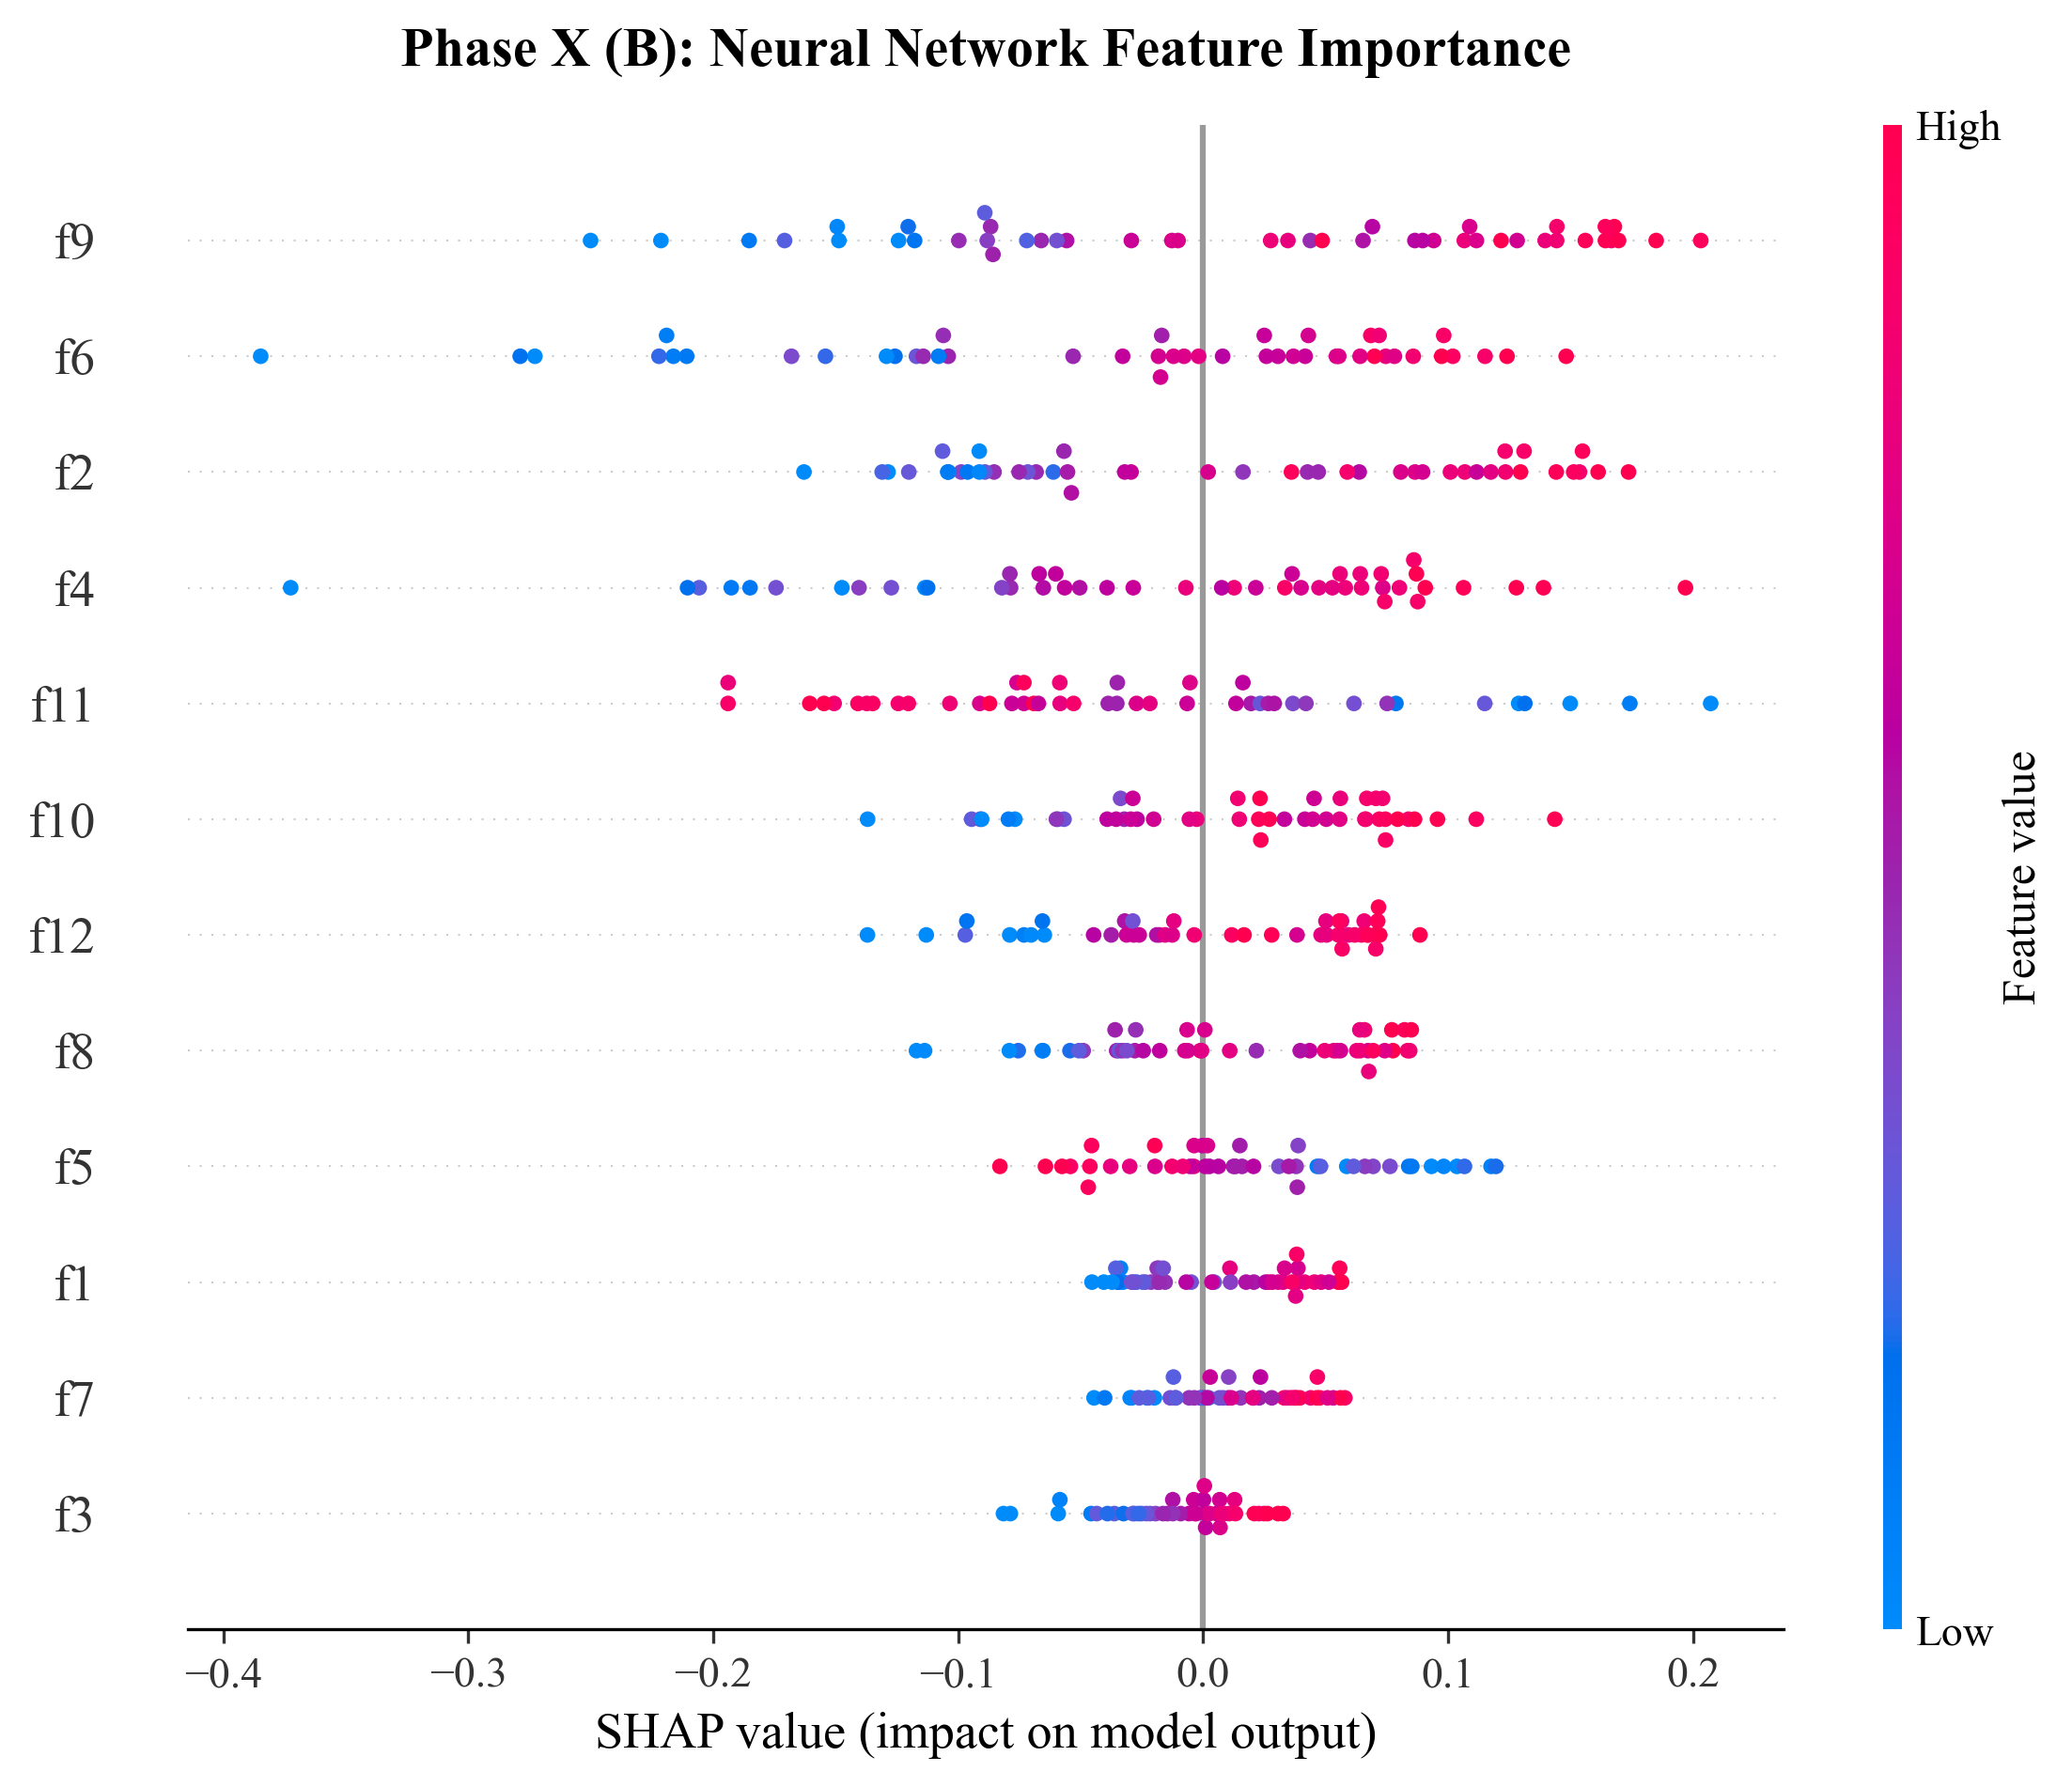

In [12]:
print("Generating SHAP values (This may take a moment for the NN)...")

# 1. SHAP for XGBoost
explainer_xgb = shap.TreeExplainer(best_models['XGBoost'])
shap_values_xgb = explainer_xgb.shap_values(x_test)

# 2. SHAP for Neural Network
background = x_train_scaled[:100]
explainer_nn = shap.DeepExplainer(best_models['Deep Neural Network'], background)
shap_values_nn = explainer_nn.shap_values(x_test_scaled)

# Extract from list if necessary (TF2 behavior)
if isinstance(shap_values_nn, list):
    shap_values_nn = shap_values_nn[0]

# Squeeze Keras 3D output to 2D
if len(shap_values_nn.shape) == 3:
    shap_values_nn = np.squeeze(shap_values_nn, axis=-1)

# ==========================================
# PUBLICATION FORMATTING
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
    'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

# ==========================================
# FIGURE 1: XGBoost SHAP
# ==========================================
plt.figure(figsize=(8, 6.5))
plt.title("Phase X (A): XGBoost Feature Importance", fontweight='bold', pad=15)

# Generate SHAP plot (show=False prevents it from rendering before we save)
shap.summary_plot(shap_values_xgb, x_test, feature_names=feature_names, show=False, plot_size=None)

plt.tight_layout()
plt.savefig('SHAP_A_XGBoost.pdf')
plt.show() # Render and clear Figure 1

# ==========================================
# FIGURE 2: Neural Network SHAP
# ==========================================
plt.figure(figsize=(8, 6.5))
plt.title("Phase X (B): Neural Network Feature Importance", fontweight='bold', pad=15)

# Generate SHAP plot
shap.summary_plot(shap_values_nn, x_test_scaled, feature_names=feature_names, show=False, plot_size=None)

plt.tight_layout()
plt.savefig('SHAP_B_Neural_Network.pdf')
plt.show() # Render and clear Figure 2

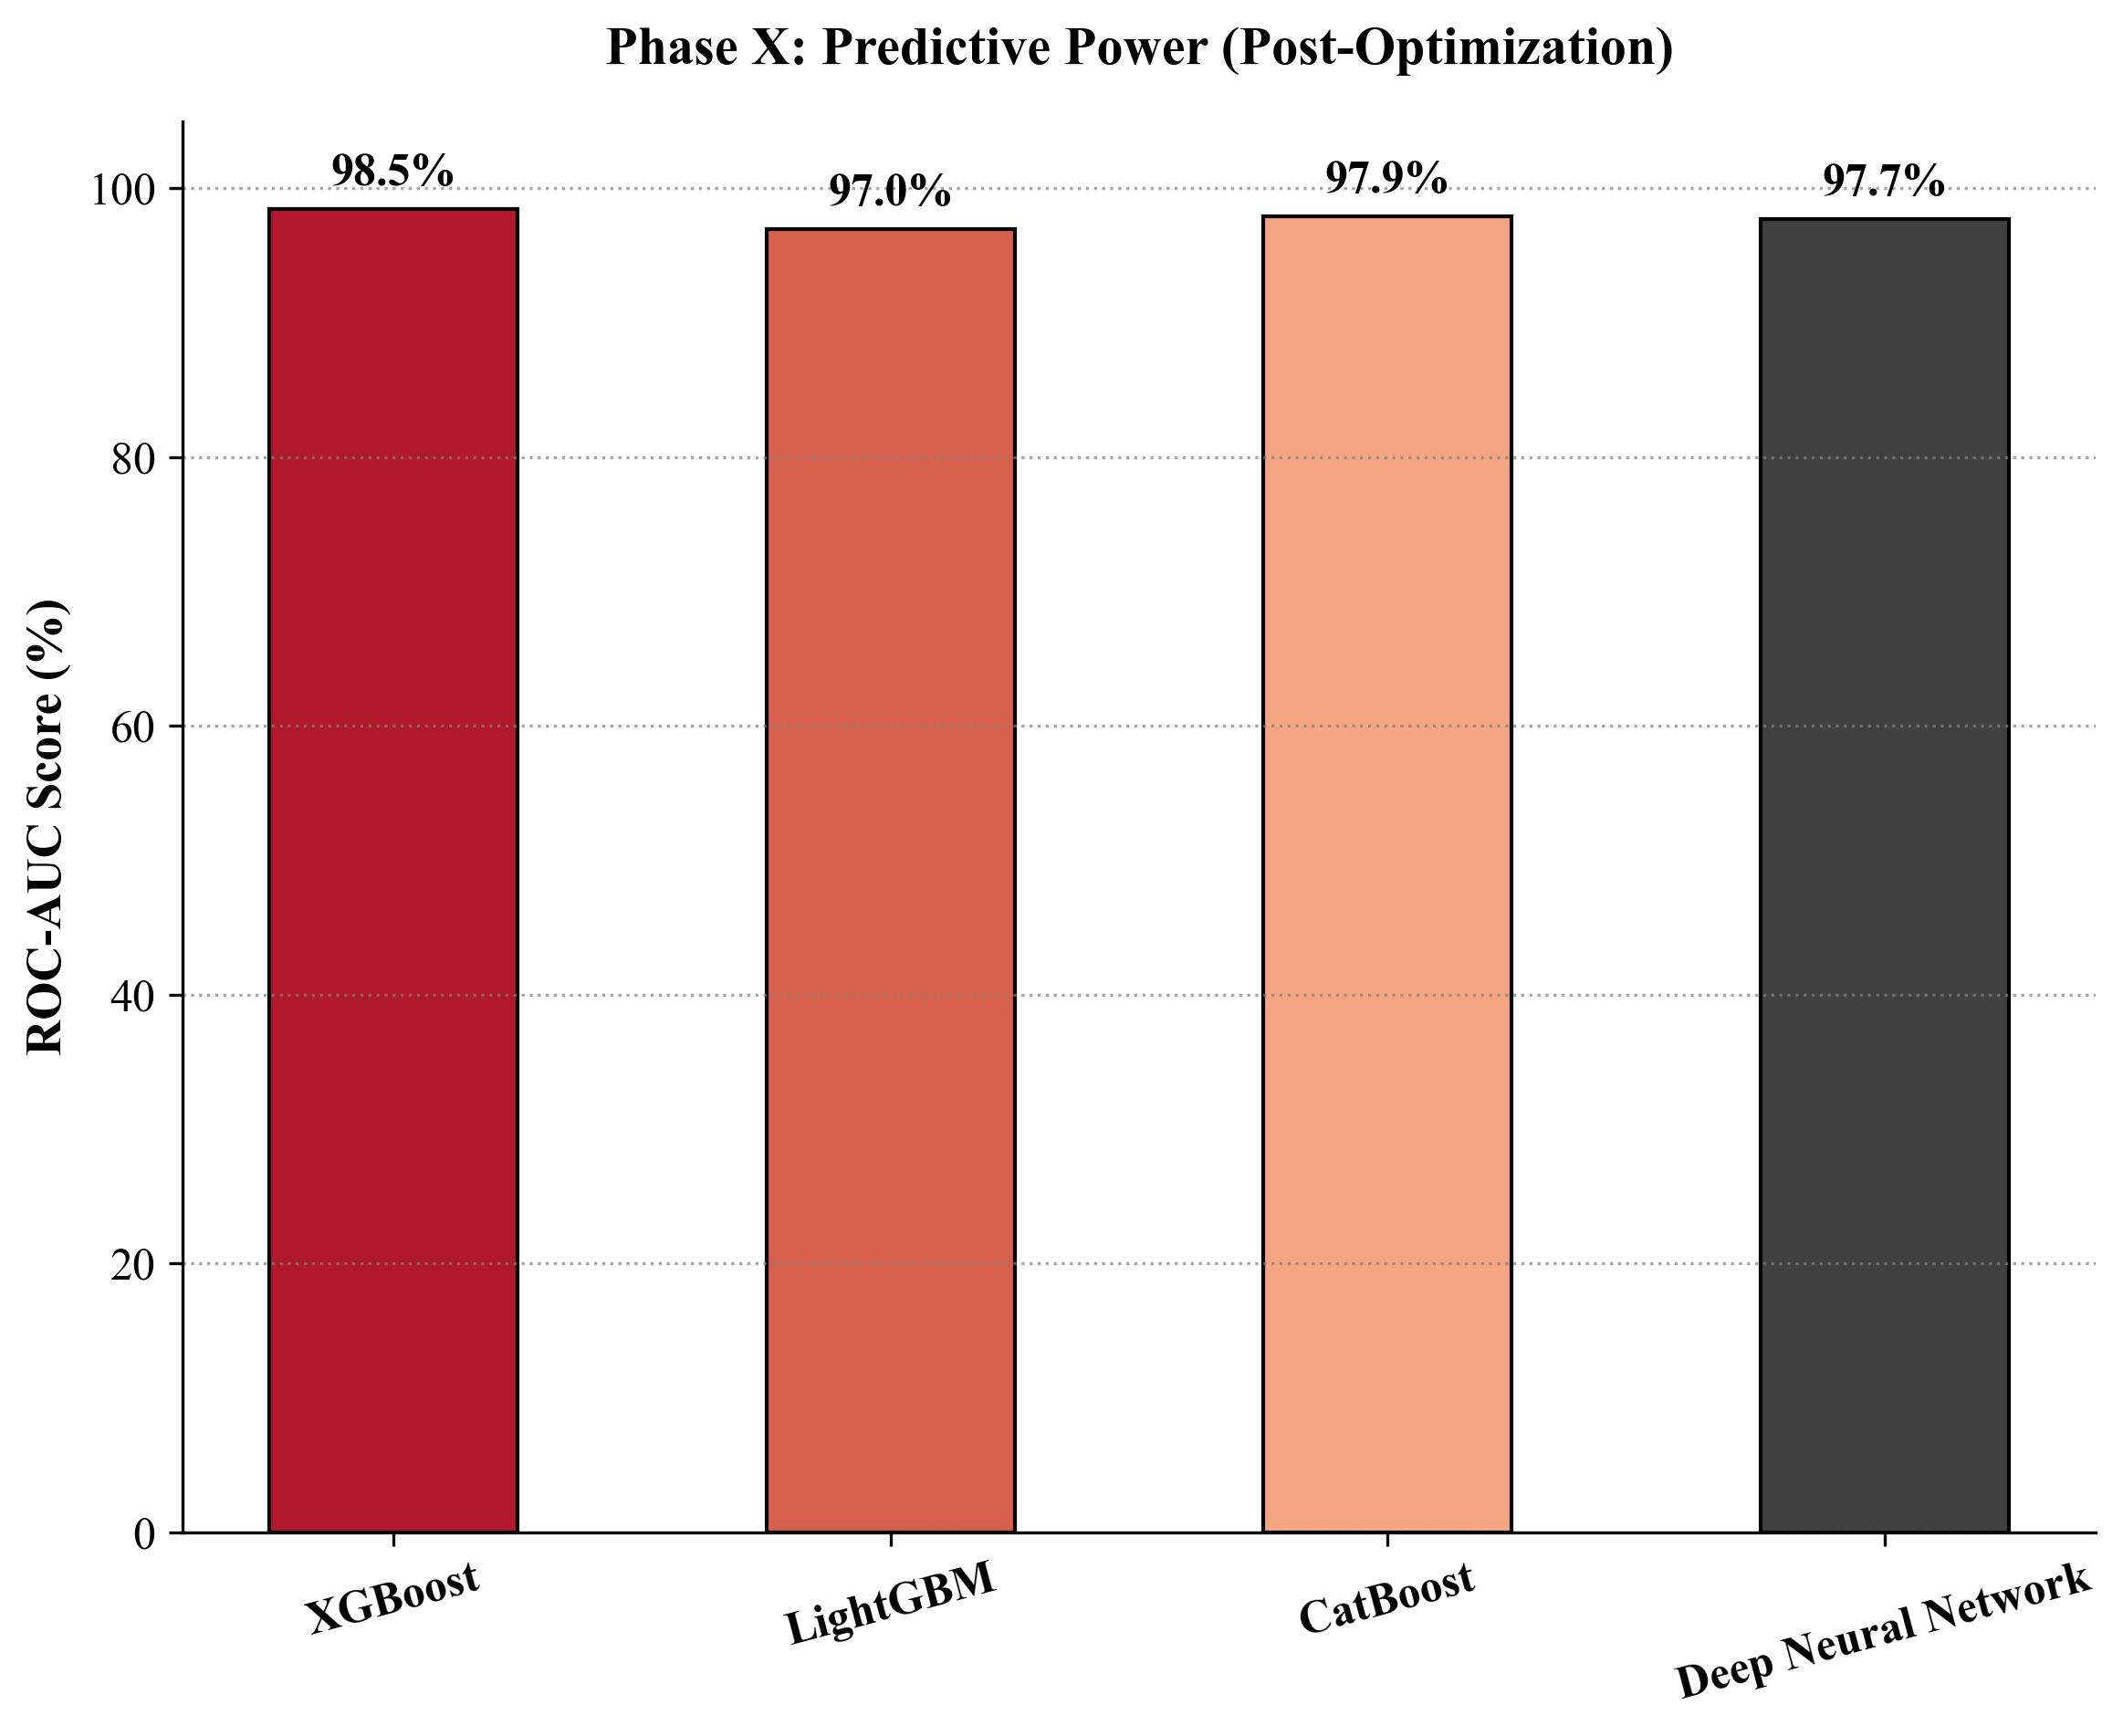

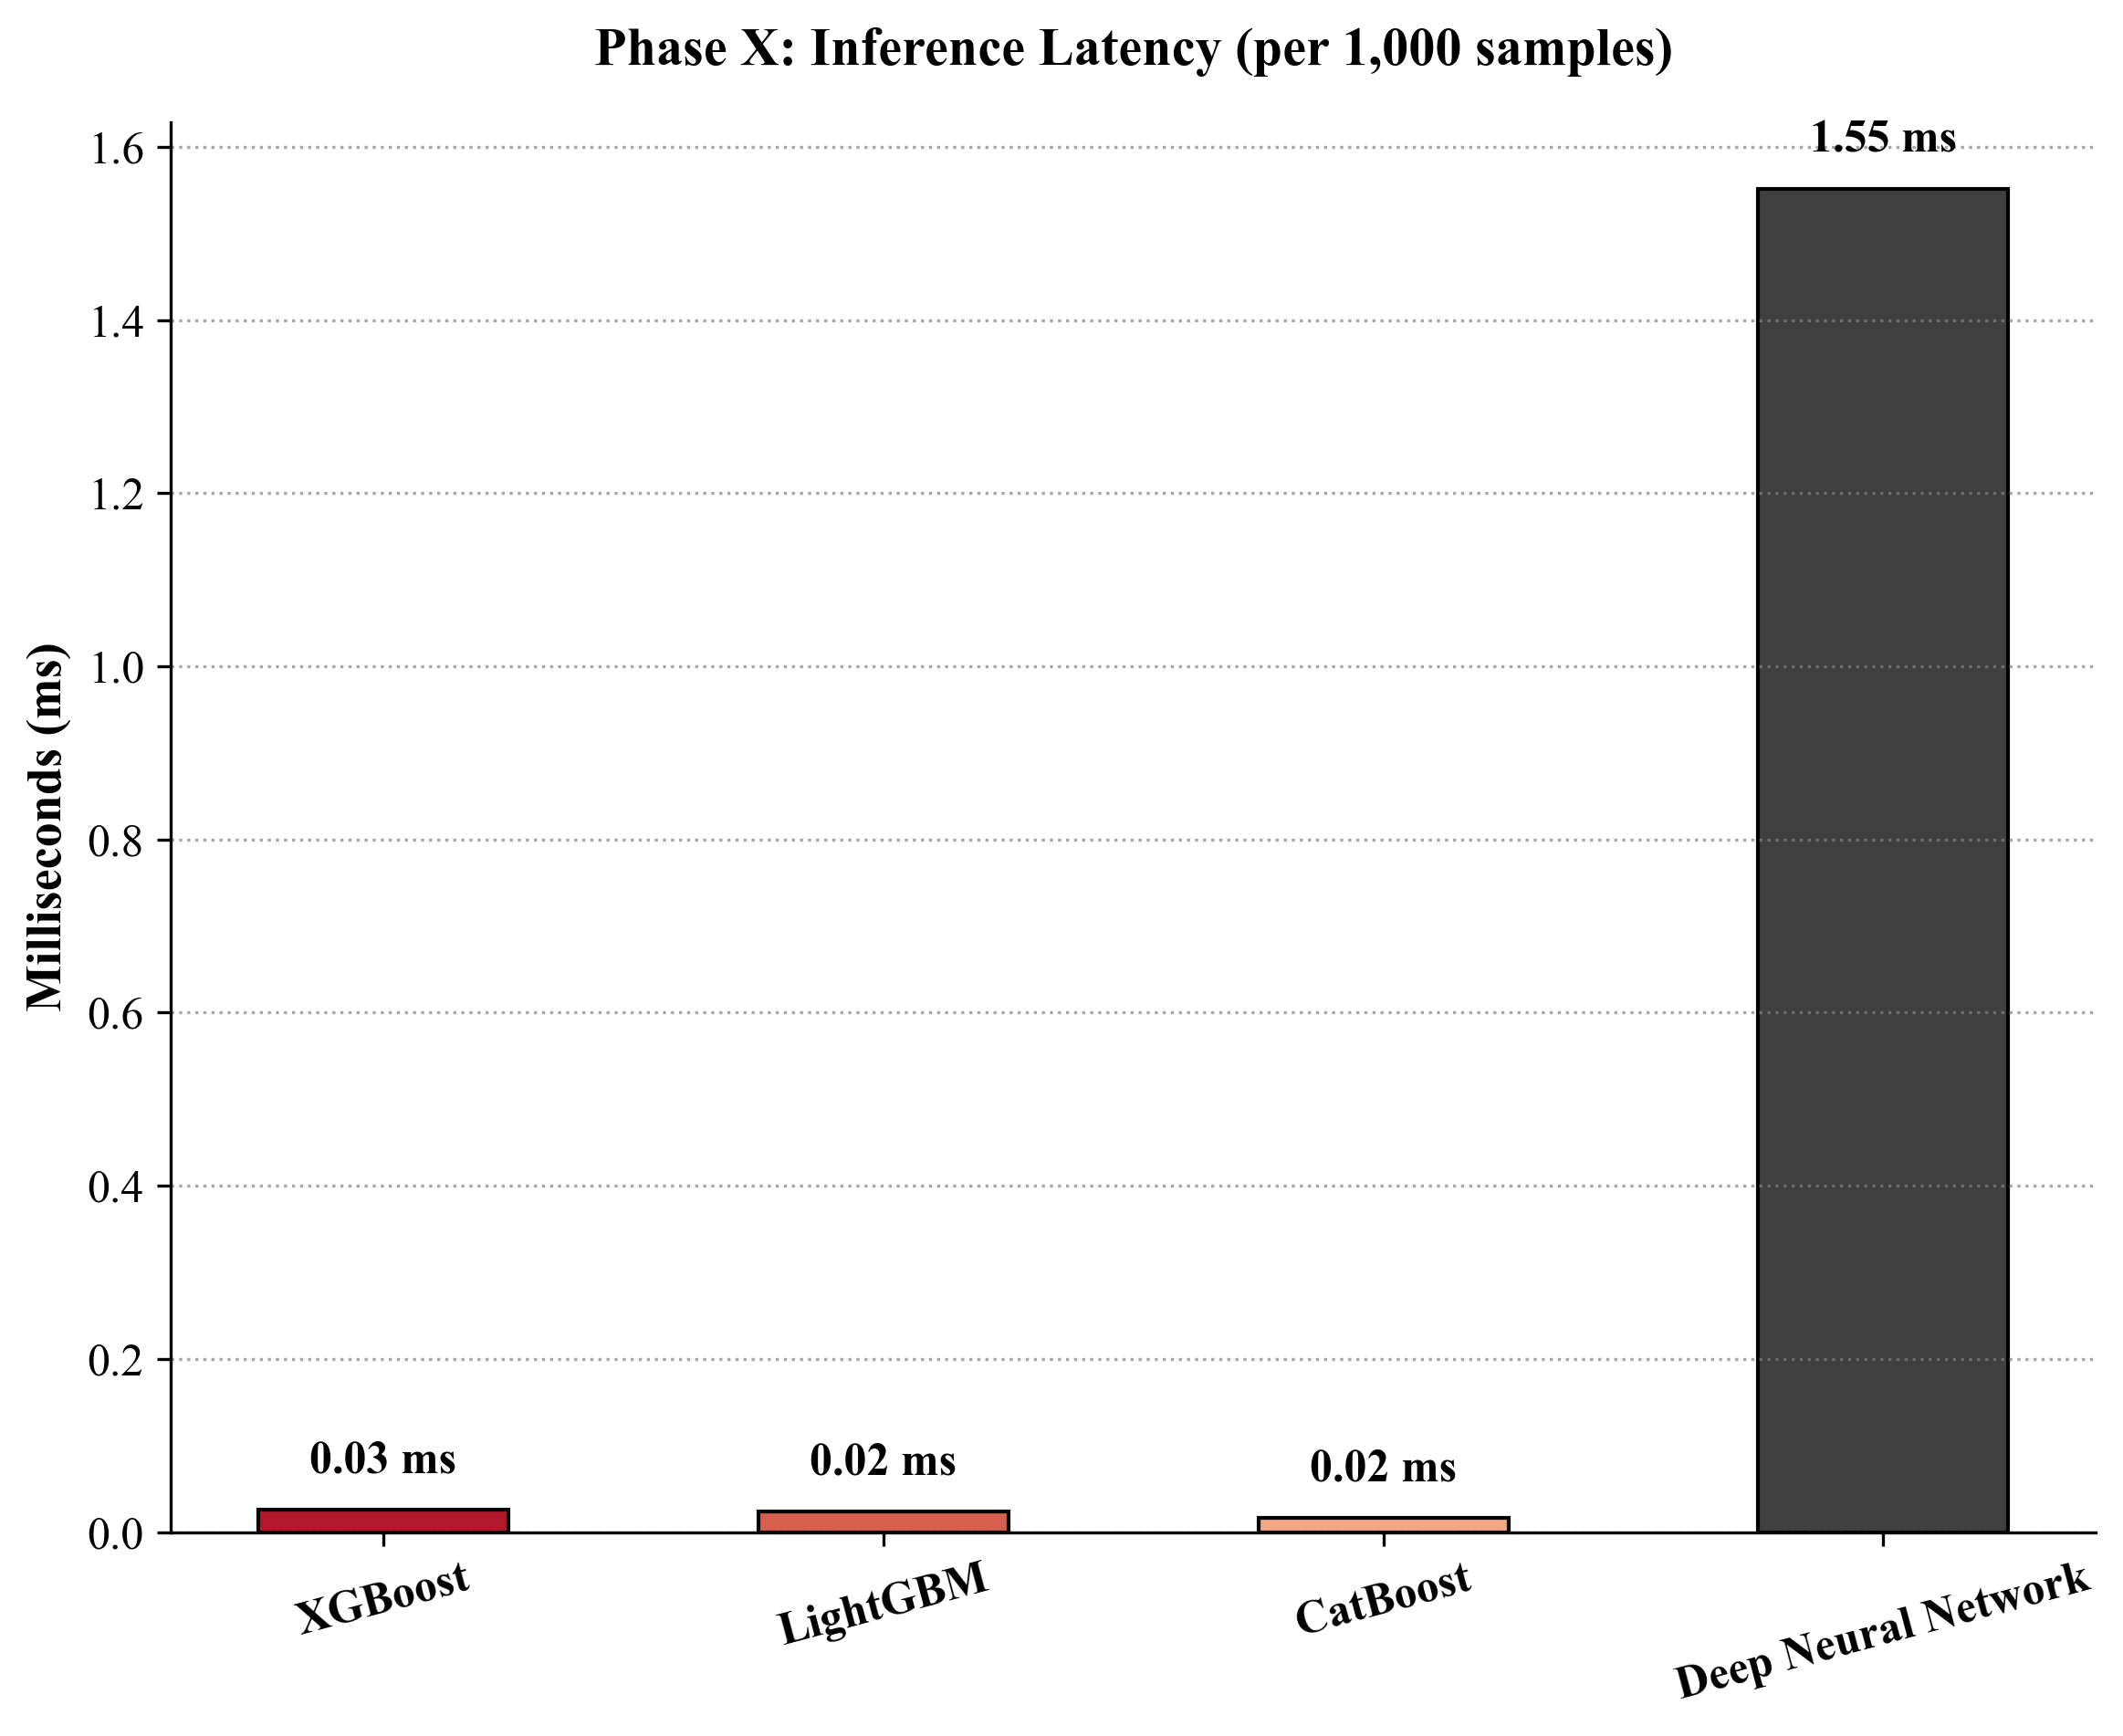

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_separated_metrics_and_latency(eval_results, latencies):
    if not eval_results or not latencies:
        print("No results to plot! Run evaluation first.")
        return
        
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'], 
        'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
        'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
    })
    
    colors = {
        'Deep Neural Network': '#404040', 
        'XGBoost': '#B2182B',             
        'LightGBM': '#D6604D',
        'CatBoost': '#F4A582'             
    }
    models = list(eval_results.keys())
    x = np.arange(len(models))
    
    # ==========================================
    # FIGURE 1: ROC-AUC Score (Predictive Power)
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(8, 6.5))
    scores = [eval_results[m]['ROC-AUC'] * 100 for m in models]
    
    bars1 = ax1.bar(x, scores, 0.5, color=[colors[m] for m in models], edgecolor='black')
    ax1.set_ylabel('ROC-AUC Score (%)', weight='bold')
    ax1.set_title('Phase X: Predictive Power (Post-Optimization)', weight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, weight='bold', rotation=15)
    ax1.set_ylim(0, 105)
    ax1.grid(axis='y', linestyle=':', color='gray', alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    for bar in bars1:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', 
                 ha='center', va='bottom', weight='bold')

    plt.tight_layout()
    plt.savefig('Tabular_Predictive_Power.pdf')
    plt.show() # Renders Figure 1

    # ==========================================
    # FIGURE 2: Inference Latency
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 6.5))
    lats = [latencies[f'{m}_Latency_ms'] for m in models]
    
    bars2 = ax2.bar(x, lats, 0.5, color=[colors[m] for m in models], edgecolor='black')
    ax2.set_ylabel('Milliseconds (ms)', weight='bold')
    ax2.set_title('Phase X: Inference Latency (per 1,000 samples)', weight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, weight='bold', rotation=15)
    ax2.grid(axis='y', linestyle=':', color='gray', alpha=0.7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    for bar in bars2:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + (max(lats)*0.02), f'{yval:.2f} ms', 
                 ha='center', va='bottom', weight='bold')

    plt.tight_layout()
    plt.savefig('Tabular_Inference_Latency.pdf')
    plt.show() # Renders Figure 2

# Execute plot
plot_separated_metrics_and_latency(evaluation_results, latency_results)

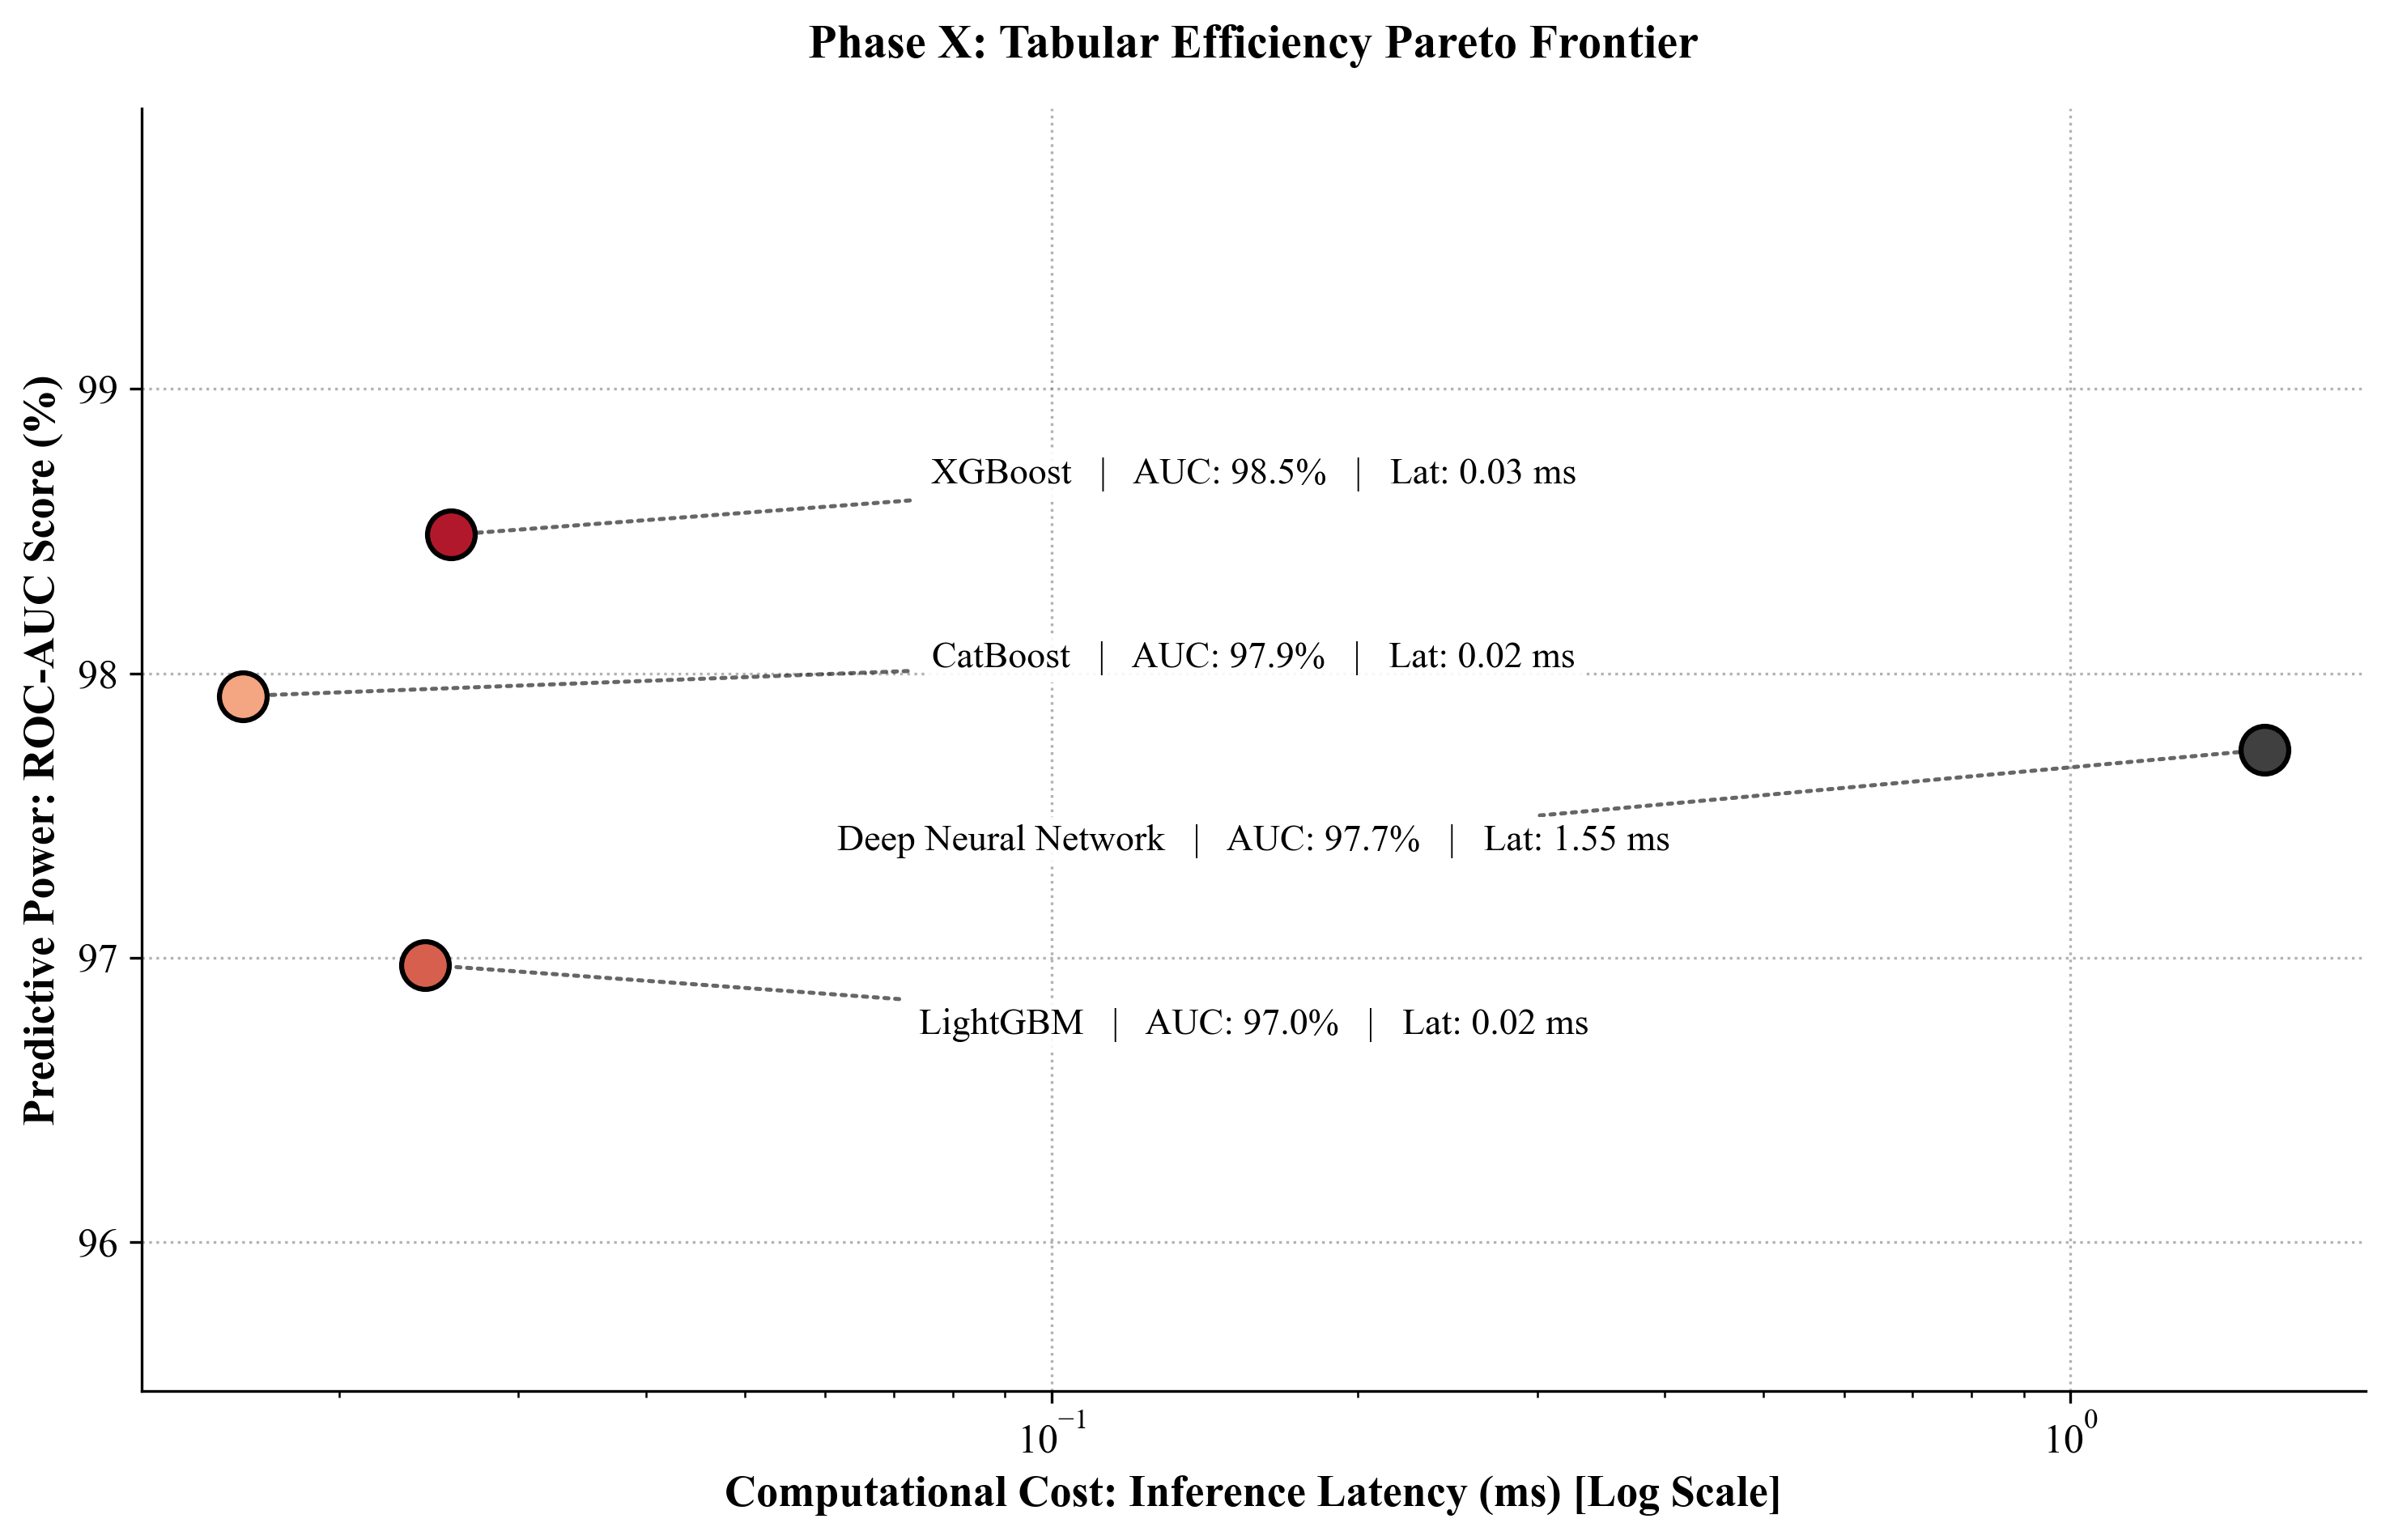

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_efficiency_tradeoff_professional(eval_results, latencies):
    if not eval_results or not latencies:
        print("No results to plot! Run evaluation first.")
        return
        
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'], 
        'font.size': 12, 'axes.labelsize': 13, 'axes.titlesize': 14,
        'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight'
    })
    
    # We keep the dots colored so the reader can distinguish the architectures, 
    # but all text and lines will be strictly black.
    colors = {
        'Deep Neural Network': '#404040', 
        'XGBoost': '#B2182B',             
        'LightGBM': '#D6604D',
        'CatBoost': '#F4A582'             
    }
    
    models = list(eval_results.keys())
    scores = [eval_results[m]['ROC-AUC'] * 100 for m in models]
    lats = [latencies[f'{m}_Latency_ms'] for m in models]

    fig, ax = plt.subplots(figsize=(10, 6.5))
    
    # 1. Plot each model as a large scatter point
    for i, m in enumerate(models):
        ax.scatter(lats[i], scores[i], color=colors[m], s=200, 
                   edgecolor='black', linewidth=1.5, zorder=3)

    # 2. Apply scales and limits
    ax.set_xscale('log')
    y_min, y_max = min(scores) - 1.5, max(scores) + 1.5
    ax.set_ylim(y_min, y_max)
    
    # 3. Calculate the center
    center_x = 10 ** ((np.log10(min(lats)) + np.log10(max(lats))) / 2)
    center_y_base = (y_min + y_max) / 2
    
    # 4. Sort models by score descending to prevent crossed lines
    sorted_indices = np.argsort(scores)[::-1]
    y_step = (y_max - y_min) / 7  # Tighter spacing for a cleaner block

    # 5. Draw the professional connected labels
    for rank, i in enumerate(sorted_indices):
        m = models[i]
        
        # Formatted as a clean, single-line academic string
        info_label = f"{m}   |   AUC: {scores[i]:.1f}%   |   Lat: {lats[i]:.2f} ms"
        
        text_y = center_y_base + (len(models)/2 - rank - 0.5) * y_step
        
        ax.annotate(
            info_label,
            xy=(lats[i], scores[i]),            
            xytext=(center_x, text_y),          
            ha='center', va='center',
            fontsize=11, color='black', # Pure black text
            # A completely transparent background with just enough white to blank out the grid
            bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none", alpha=0.9),
            # Professional thin, dotted black connector lines
            arrowprops=dict(arrowstyle="-", color='black', linestyle=':', lw=1.2, alpha=0.6, shrinkA=5, shrinkB=8),
            zorder=2
        )

    # Labeling
    ax.set_ylabel('Predictive Power: ROC-AUC Score (%)', weight='bold')
    ax.set_xlabel('Computational Cost: Inference Latency (ms) [Log Scale]', weight='bold')
    ax.set_title('Phase X: Tabular Efficiency Pareto Frontier', weight='bold', pad=15)
    
    # Grid and Spines
    ax.grid(True, linestyle=':', color='gray', alpha=0.6, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('Efficiency_Tradeoff_Professional.pdf')
    plt.show()

# Execute plot
plot_efficiency_tradeoff_professional(evaluation_results, latency_results)